# DroneWaste — Entrenamiento del Clasificador de Contenedores

**Modelo:** MobileNetV3-Small (Transfer Learning desde ImageNet)  
**Clases:** VACIO · BAJO · MEDIO · ALTO · DESBORDADO  
**Salida:** `model.pt` (TorchScript — listo para el servidor FastAPI)

## Antes de empezar
1. Coloca las imágenes en `../dataset/<CLASE>/imagen.jpg`
2. Mínimo 50 imágenes por clase (200+ recomendado)
3. Consulta `../dataset/README.md` para fuentes de imágenes

In [1]:
# Instala dependencias si aún no están
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch', 'torchvision', 'pillow', 'scikit-learn',
                'matplotlib', 'seaborn'], check=True)
print('Dependencias listas')

Dependencias listas


In [2]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision import datasets, models
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import json

print(f'PyTorch {torch.__version__} | GPU disponible: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando: {DEVICE}')

PyTorch 2.10.0+cpu | GPU disponible: False
Usando: cpu


## Configuración de hiperparámetros

In [3]:
# ── Rutas ────────────────────────────────────────────────────────────────────
DATASET_DIR = Path('../dataset')       # carpetas VACIO/ BAJO/ MEDIO/ ALTO/ DESBORDADO/
MODEL_OUT   = Path('model.pt')         # TorchScript exportado
LABELS_OUT  = Path('labels.json')      # ya existe, solo verificamos

# ── Hiperparámetros ──────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16      # bajar a 8 si hay problemas de memoria
EPOCHS      = 20      # 10-20 suele ser suficiente con transfer learning
LR          = 3e-4    # learning rate para el clasificador (capas finales)
LR_BACKBONE = 1e-5    # learning rate más bajo para las capas preentrenadas
VAL_SPLIT   = 0.2     # 20% de validación
CLASSES     = ['VACIO', 'BAJO', 'MEDIO', 'ALTO', 'DESBORDADO']

print('Configuración cargada')
print(f'Dataset en: {DATASET_DIR.resolve()}')

Configuración cargada
Dataset en: C:\Users\timon\DroneWaste\DroneWaste_ai\dataset


## Verificar dataset

In [4]:
print('Distribución del dataset:')
total = 0
for cls in CLASSES:
    folder = DATASET_DIR / cls
    if folder.exists():
        n = len(list(folder.glob('*.[jJpPwW][pPnNbB][gGeEpP]*')))
        total += n
        status = '✓' if n >= 50 else ('⚠ (mínimo 50)' if n > 0 else '✗ VACÍA')
        print(f'  {cls:>12}: {n:>4} imágenes  {status}')
    else:
        print(f'  {cls:>12}:    0 imágenes  ✗ CARPETA NO EXISTE')
print(f'  {"TOTAL":>12}: {total:>4} imágenes')

if total < 5 * 50:
    print('\n⚠ AVISO: Pocas imágenes. El modelo puede sobreajustarse.')
    print('Consulta dataset/README.md para obtener más datos.')

Distribución del dataset:
         VACIO:  130 imágenes  ✓
          BAJO:   51 imágenes  ✓
         MEDIO:  257 imágenes  ✓
          ALTO:  159 imágenes  ✓
    DESBORDADO:  165 imágenes  ✓
         TOTAL:  762 imágenes


## Transforms y DataLoaders

In [5]:
# Augmentación para entrenamiento (simula condiciones de vuelo de dron)
train_transform = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.3, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Sin augmentación para validación/test
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar dataset completo con clases ordenadas (ALTO=0, BAJO=1... según carpetas)
full_dataset = datasets.ImageFolder(str(DATASET_DIR))
print(f'Clases detectadas: {full_dataset.class_to_idx}')

# Split train/val reproducible
n_val   = int(len(full_dataset) * VAL_SPLIT)
n_train = len(full_dataset) - n_val
train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# Aplicar transforms diferentes a cada split
train_set.dataset.transform = train_transform
val_copy = datasets.ImageFolder(str(DATASET_DIR), transform=val_transform)
val_set  = torch.utils.data.Subset(val_copy, val_set.indices)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {n_train} imgs | Val: {n_val} imgs')

Clases detectadas: {'ALTO': 0, 'BAJO': 1, 'DESBORDADO': 2, 'MEDIO': 3, 'VACIO': 4}
Train: 610 imgs | Val: 152 imgs


## Modelo — MobileNetV3-Small con Transfer Learning

In [6]:
# Cargar MobileNetV3-Small preentrenado en ImageNet
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Reemplazar el clasificador final para 5 clases
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, len(CLASSES))

model = model.to(DEVICE)

# Optimizador con dos learning rates:
#   - backbone (capas preentrenadas): LR muy bajo para no destruir el conocimiento
#   - clasificador (capas nuevas):    LR normal
backbone_params    = [p for n, p in model.named_parameters() if 'classifier.3' not in n]
classifier_params  = model.classifier[3].parameters()

optimizer = optim.Adam([
    {'params': backbone_params,   'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
print(f'Modelo listo — {total_params/1e6:.1f}M parámetros')
print(f'Clasificador: {in_features} → {len(CLASSES)} clases')

Modelo listo — 1.5M parámetros
Clasificador: 1024 → 5 clases


## Entrenamiento

In [7]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Entrenamiento ────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()

    # ── Validación ───────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits  = model(imgs)
            loss    = criterion(logits, labels)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()

    scheduler.step()

    t_loss = train_loss / n_train
    t_acc  = train_correct / n_train * 100
    v_loss = val_loss / n_val
    v_acc  = val_correct / n_val * 100
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    flag = ''
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), 'best_weights.pt')
        flag = '  ← mejor'

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={t_loss:.4f}  train_acc={t_acc:.1f}%  '
          f'val_loss={v_loss:.4f}  val_acc={v_acc:.1f}%{flag}')

print(f'\nMejor val_acc: {best_val_acc:.1f}%')

Epoch 01/20  train_loss=1.5367  train_acc=31.6%  val_loss=1.3583  val_acc=47.4%  ← mejor
Epoch 02/20  train_loss=1.3173  train_acc=49.3%  val_loss=1.2294  val_acc=55.3%  ← mejor
Epoch 03/20  train_loss=1.1926  train_acc=56.4%  val_loss=1.1528  val_acc=55.3%
Epoch 04/20  train_loss=1.0975  train_acc=58.9%  val_loss=1.1143  val_acc=59.2%  ← mejor
Epoch 05/20  train_loss=1.0277  train_acc=63.6%  val_loss=1.0835  val_acc=59.9%  ← mejor
Epoch 06/20  train_loss=0.9640  train_acc=66.4%  val_loss=1.0638  val_acc=59.2%
Epoch 07/20  train_loss=0.9160  train_acc=69.3%  val_loss=1.0509  val_acc=60.5%  ← mejor
Epoch 08/20  train_loss=0.8981  train_acc=69.3%  val_loss=1.0352  val_acc=61.8%  ← mejor
Epoch 09/20  train_loss=0.8462  train_acc=70.5%  val_loss=1.0274  val_acc=62.5%  ← mejor
Epoch 10/20  train_loss=0.8130  train_acc=73.6%  val_loss=1.0269  val_acc=61.8%
Epoch 11/20  train_loss=0.8163  train_acc=72.6%  val_loss=1.0186  val_acc=61.8%
Epoch 12/20  train_loss=0.7923  train_acc=72.8%  val_loss

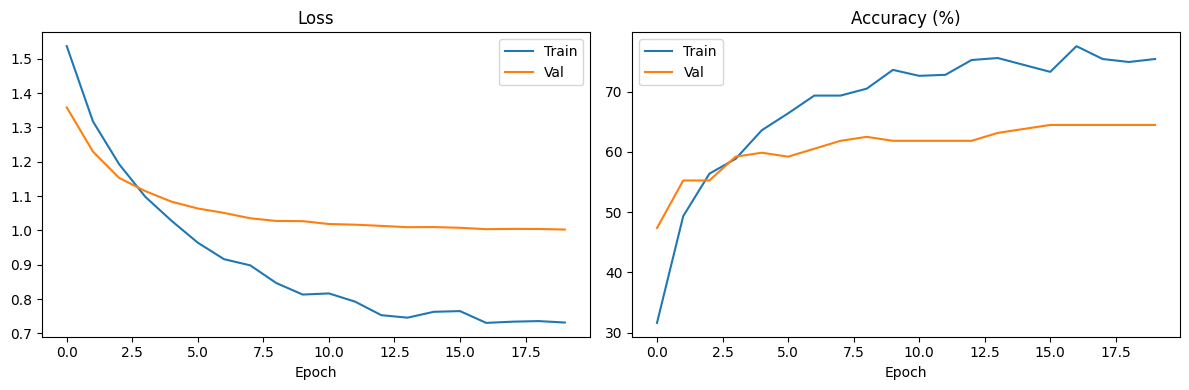

Curvas guardadas en training_curves.png


In [8]:
# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print('Curvas guardadas en training_curves.png')

## Evaluación — Matriz de Confusión

Reporte de clasificación:
              precision    recall  f1-score   support

        ALTO       0.50      0.43      0.46        30
        BAJO       0.75      0.43      0.55         7
  DESBORDADO       0.71      0.64      0.68        39
       MEDIO       0.76      0.77      0.77        57
       VACIO       0.45      0.68      0.54        19

    accuracy                           0.64       152
   macro avg       0.63      0.59      0.60       152
weighted avg       0.66      0.64      0.64       152



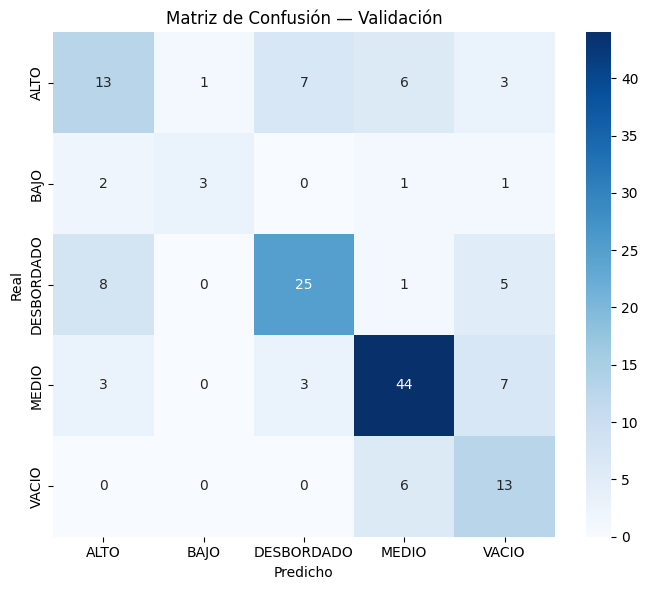

In [9]:
# Cargar los mejores pesos
model.load_state_dict(torch.load('best_weights.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Obtener nombres de clase en el orden correcto
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
class_names  = [idx_to_class[i] for i in range(len(CLASSES))]

print('Reporte de clasificación:')
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de Confusión — Validación')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## Exportar a TorchScript (para el servidor FastAPI)

In [10]:
# Exportar como TorchScript — compatible con main.py sin depender de la definición del modelo
model.eval()
example_input = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
scripted = torch.jit.trace(model, example_input)
scripted.save(str(MODEL_OUT))

size_mb = MODEL_OUT.stat().st_size / 1024 / 1024
print(f'Modelo exportado: {MODEL_OUT} ({size_mb:.1f} MB)')

# Verificar que labels.json tiene el orden correcto
labels_dict = {str(v): k for k, v in full_dataset.class_to_idx.items()}
with open(LABELS_OUT, 'w') as f:
    json.dump(labels_dict, f, ensure_ascii=False, indent=2)
print(f'Labels actualizados: {labels_dict}')
print('\n✓ Listo. Reinicia el servidor FastAPI para cargar el nuevo modelo.')
print('  cd DroneWaste_ai && uvicorn main:app --reload')

Modelo exportado: model.pt (6.2 MB)
Labels actualizados: {'0': 'ALTO', '1': 'BAJO', '2': 'DESBORDADO', '3': 'MEDIO', '4': 'VACIO'}

✓ Listo. Reinicia el servidor FastAPI para cargar el nuevo modelo.
  cd DroneWaste_ai && uvicorn main:app --reload
